# Modèles de Machine Learning classiques

In [1]:
import pandas as pd
import numpy as np

In [2]:
# Chargement du dataset
df = pd.read_csv('df_processed.csv')
df

,id,title,text,subject,date,label,tokens,flesch_reading_ease,flesch_kincaid_grade,text_length,word_count,flesch_score,flesch_kincaid,caps_ratio,exclamation_count,question_count
0,1,"""Breaking: New Study Finds Coffee Extends Lif...","""Researchers claim drinking 5 cups daily adds...",politics,2024-01-15,0,"['Researchers', 'claim', 'drinking', 'cups', '...",81.855000,4.823333,69,12,81.855000,4.823333,0.014493,0,0
1,2,"""Celebrities Unite for Secret Project""","""Multiple A-list actors spotted meeting in un...",entertainment,2024-01-16,0,"['Multiple', 'actors', 'spotted', 'meeting', '...",8.365000,14.080000,65,8,8.365000,14.080000,0.030769,0,0
2,3,"""Economic Boom Expected This Quarter""","""Analysts predict 8% growth despite market co...",business,2024-01-17,0,"['Analysts', 'predict', 'growth', 'despite', '...",42.615714,9.054286,53,7,42.615714,9.054286,0.018868,0,0
3,4,"""Tech Giant Announces Revolutionary Invention""","""Company claims to have solved climate change...",science,2024-01-18,0,"['Company', 'claims', 'solved', 'climate', 'ch...",78.245000,4.830000,63,10,78.245000,4.830000,0.015873,0,0
4,5,"""Local Hero Saves 100 People in One Day""","""Unknown citizen rescues families from disaster""",world,2024-01-19,0,"['Unknown', 'citizen', 'rescues', 'families', ...",3.345000,14.283333,49,6,3.345000,14.283333,0.020408,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,102,Jazz Festival Attracts International Musicians,Festival celebrates diverse musical styles and...,entertainment,2025-11-08,1,"['Festival', 'celebrates', 'diverse', 'musical...",6.358571,14.111429,58,7,6.358571,14.111429,0.017241,0,0
207,103,Ocean Temperature Monitoring Reveals Warming T...,Scientists document rate of change in marine e...,climate,2025-11-07,1,"['Scientists', 'document', 'rate', 'change', '...",29.515000,11.130000,58,8,29.515000,11.130000,0.017241,0,0
208,104,New Antibiotic Effective Against Resistant Bac...,Pharmaceutical breakthrough addresses critical...,health,2025-11-06,1,"['Pharmaceutical', 'breakthrough', 'addresses'...",-67.155000,24.116667,68,6,-67.155000,24.116667,0.014706,0,0
209,105,Venture Capital Funding Reaches Record Levels,Investors allocate billions to promising start...,business,2025-11-05,1,"['Investors', 'allocate', 'billions', 'promisi...",3.345000,14.283333,50,6,3.345000,14.283333,0.020000,0,0


#### Extraction de caractéristiques

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorisation TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
    ngram_range=(1, 2)  # unigrams et bigrams
)

# Combiner titre et texte, en gérant les valeurs manquantes
df['combined_text'] = (
    df['title'].fillna('') + ' ' + df['text'].fillna('')
)

# Remplacer les valeurs manquantes éventuelles dans la colonne combinée
combined_text = df['combined_text'].fillna('')

X_tfidf = tfidf.fit_transform(combined_text)

print(f"Shape des features TF-IDF: {X_tfidf.shape}")

Shape des features TF-IDF: (211, 550)


#### 1- Modèle avec features engineered

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

In [5]:
# Features numériques
feature_cols = ['flesch_reading_ease', 'flesch_kincaid_grade', 'text_length', 'word_count', 'flesch_score', 'flesch_kincaid', 'caps_ratio', 'exclamation_count', 'question_count']

X_features = df[feature_cols].fillna(0)
y = df['label']

# Division train/test
X_train_feat, X_test_feat, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42, stratify=y
)

#### Entraînement Random Forest

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_feat, y_train)

# Prédictions
y_pred = rf_model.predict(X_test_feat)
y_prob = rf_model.predict_proba(X_test_feat)[:, 1]  # Probabilité classe positive

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.930

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        21
           1       0.91      0.95      0.93        22

    accuracy                           0.93        43
   macro avg       0.93      0.93      0.93        43
weighted avg       0.93      0.93      0.93        43



#### 2- Modèle TF-IDF + Logistic Regression

In [7]:
# Logistic Regression with TF-IDF features
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_feat, y_train)

# Prédictions
y_pred_lr = lr_model.predict(X_test_feat)
y_prob_lr = lr_model.predict_proba(X_test_feat)[:, 1]

print(f"TF-IDF + Logistic Regression Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))


TF-IDF + Logistic Regression Accuracy: 0.930

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.90      0.93        21
           1       0.91      0.95      0.93        22

    accuracy                           0.93        43
   macro avg       0.93      0.93      0.93        43
weighted avg       0.93      0.93      0.93        43



#### XGBoost

In [8]:
# XGBoost
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train_feat, y_train)

y_pred_xgb = xgb_model.predict(X_test_feat)
y_prob_xgb = xgb_model.predict_proba(X_test_feat)[:, 1]

print(f"TF-IDF + XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb):.3f}")

TF-IDF + XGBoost Accuracy: 0.930


#### 3-Modèle Transformer (BERT)

##### 3.1 - Préparation pour BERT

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import TrainingArguments, Trainer
import torch
from torch.utils.data import Dataset
from tqdm.auto import tqdm

In [10]:
class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [11]:
# Initialisation du modèle BERT
model_name = 'bert-base-uncased'  # ou 'camembert-base' pour le français
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=2
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [12]:
from sklearn.preprocessing import LabelEncoder
#Conversion des labels en entiers
def prepare_labels(df):
    """Convertit les labels en format numérique"""
    if df['label'].dtype == 'object':  # Si c'est des strings
        le = LabelEncoder()
        df['label_encoded'] = le.fit_transform(df['label'])
        print(f"Mapping des labels: {dict(zip(le.classes_, le.transform(le.classes_)))}")
        return df['label_encoded'].values, le
    else:
        return df['label'].values, None

##### 3.2 Entraînement BERT3

In [13]:
# Préparation des données - CORRECTION COMPLÈTE
print("Préparation des données...")

# 1. Conversion des labels
y_encoded, label_encoder = prepare_labels(df)

# 2. Préparation des textes
X_text = df['combined_text'].fillna('').values

# 3. Division train/test
X_train_text, X_test_text, y_train_bert, y_test_bert = train_test_split(
    X_text, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Taille train: {len(X_train_text)}, Taille test: {len(X_test_text)}")
print(f"Distribution labels train: {np.bincount(y_train_bert)}")

# 4. Créer les datasets pour BERT
train_dataset = NewsDataset(X_train_text, y_train_bert, tokenizer)
test_dataset = NewsDataset(X_test_text, y_test_bert, tokenizer)

# Arguments d'entraînement (version corrigée)
training_args = TrainingArguments(
    output_dir='../results',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='../logs',
    eval_strategy="epoch",  # Changé de evaluation_strategy à eval_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to=[],  # Désactive les logs WandB/TensorBoard si non configurés
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

# Entraînement
trainer.train()

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Préparation des données...
Taille train: 168, Taille test: 43
Distribution labels train: [84 84]


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss
1,No log,0.619550
2,No log,0.407909
3,No log,0.196297


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=63, training_loss=0.5272572229778956, metrics={'train_runtime': 3604.1577, 'train_samples_per_second': 0.14, 'train_steps_per_second': 0.017, 'total_flos': 132607971901440.0, 'train_loss': 0.5272572229778956, 'epoch': 3.0})

In [15]:
# Evaluation
eval_results = trainer.evaluate()
print(f"Résultats d'évaluation: {eval_results}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Résultats d'évaluation: {'eval_loss': 0.1962966024875641, 'eval_runtime': 73.6821, 'eval_samples_per_second': 0.584, 'eval_steps_per_second': 0.081, 'epoch': 3.0}


# Comparaison des modèles

Évaluation des modèles...

Prédictions BERT...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



COMPARAISON DES MODÈLES
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Random Forest    0.9302      0.913  0.9545    0.9333   0.9805
Logistic Regression    0.9302      0.913  0.9545    0.9333   0.9740
            XGBoost    0.9302      0.913  0.9545    0.9333   0.9578
               BERT    1.0000      1.000  1.0000    1.0000   1.0000


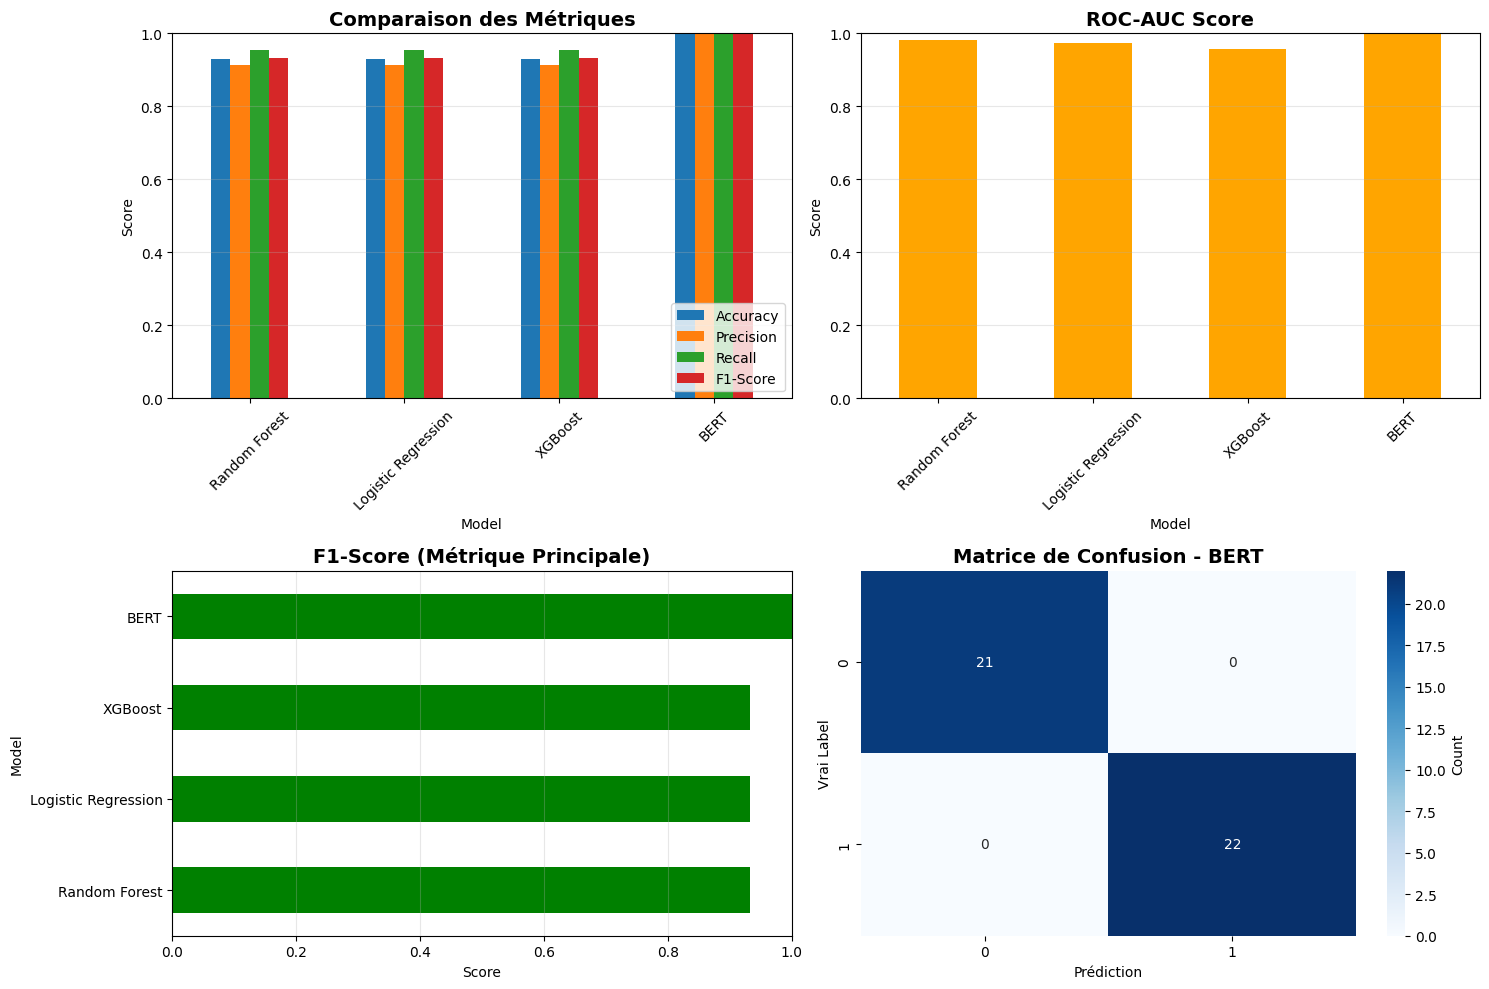


🏆 MEILLEUR MODÈLE: BERT
   F1-Score: 1.0000
   Accuracy: 1.0000
   ROC-AUC: 1.0000


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import time

# Dictionnaire pour stocker les résultats
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': []
}

# Fonction d'évaluation générique
def evaluate_model(model_name, y_true, y_pred, y_prob):
    results['Model'].append(model_name)
    results['Accuracy'].append(accuracy_score(y_true, y_pred))
    results['Precision'].append(precision_score(y_true, y_pred))
    results['Recall'].append(recall_score(y_true, y_pred))
    results['F1-Score'].append(f1_score(y_true, y_pred))
    results['ROC-AUC'].append(roc_auc_score(y_true, y_prob))

# Évaluer tous les modèles
print("Évaluation des modèles...")

# 1. Random Forest
evaluate_model('Random Forest', y_test, y_pred, y_prob)

# 2. Logistic Regression
evaluate_model('Logistic Regression', y_test, y_pred_lr, y_prob_lr)

# 3. XGBoost
evaluate_model('XGBoost', y_test, y_pred_xgb, y_prob_xgb)

# 4. BERT - obtenir les prédictions
print("\nPrédictions BERT...")
predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=1)
y_prob_bert = torch.softmax(torch.tensor(predictions.predictions), dim=1)[:, 1].numpy()
evaluate_model('BERT', y_test_bert, y_pred_bert, y_prob_bert)

# Créer un DataFrame de comparaison
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.round(4)
print("\n" + "="*60)
print("COMPARAISON DES MODÈLES")
print("="*60)
print(comparison_df.to_string(index=False))
print("="*60)

# Visualisation des métriques
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Comparaison des métriques principales
comparison_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=axes[0, 0], rot=45
)
axes[0, 0].set_title('Comparaison des Métriques', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Score')
axes[0, 0].legend(loc='lower right')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. ROC-AUC
comparison_df.set_index('Model')['ROC-AUC'].plot(kind='bar', ax=axes[0, 1], color='orange', rot=45)
axes[0, 1].set_title('ROC-AUC Score', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Comparaison F1-Score (métrique clé pour fake news)
comparison_df.set_index('Model')['F1-Score'].plot(kind='barh', ax=axes[1, 0], color='green')
axes[1, 0].set_title('F1-Score (Métrique Principale)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Score')
axes[1, 0].set_xlim([0, 1])
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Matrice de confusion (meilleur modèle = BERT probablement)
best_model_idx = comparison_df['F1-Score'].idxmax()
best_model_name = comparison_df.loc[best_model_idx, 'Model']

if best_model_name == 'BERT':
    cm = confusion_matrix(y_test_bert, y_pred_bert)
elif best_model_name == 'Random Forest':
    cm = confusion_matrix(y_test, y_pred)
elif best_model_name == 'Logistic Regression':
    cm = confusion_matrix(y_test, y_pred_lr)
else:  # XGBoost
    cm = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 1], cbar_kws={'label': 'Count'})
axes[1, 1].set_title(f'Matrice de Confusion - {best_model_name}', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Vrai Label')
axes[1, 1].set_xlabel('Prédiction')

plt.tight_layout()
plt.show()

# Afficher le meilleur modèle
print(f"\n🏆 MEILLEUR MODÈLE: {best_model_name}")
print(f"   F1-Score: {comparison_df.loc[best_model_idx, 'F1-Score']:.4f}")
print(f"   Accuracy: {comparison_df.loc[best_model_idx, 'Accuracy']:.4f}")
print(f"   ROC-AUC: {comparison_df.loc[best_model_idx, 'ROC-AUC']:.4f}")

In [14]:
# Sauvegarde
model.save_pretrained('./fake-news-bert')
tokenizer.save_pretrained('./fake-news-bert')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./fake-news-bert/tokenizer_config.json', './fake-news-bert/tokenizer.json')